In [15]:
# Step 1: Import Necessary Libraries
print("Step 1: Importing libraries...")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
import joblib
from wordcloud import WordCloud

# Set plot style for better visualizations
sns.set_style('whitegrid')
print("Libraries imported successfully.\n")

Step 1: Importing libraries...
Libraries imported successfully.



In [17]:
# Step 2: Mount Google Drive and Load Preprocessed Data
print("Step 2: Loading preprocessed data from Google Drive...")

try:
    # Mount Google Drive if not already mounted
    if not os.path.isdir('/content/drive/My Drive'):
        drive.mount('/content/drive')

    # --- IMPORTANT ---
    # Please update this path to the location of your preprocessed CSV file in your Google Drive.
    # For example: '/content/drive/MyDrive/your_project_folder/ngrams_extracted.csv'
    file_path = '/content/drive/MyDrive/AIML assignment/results/preprocessed_reviews.csv'

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file was not found at '{file_path}'. Please double-check the path.")

    df = pd.read_csv(file_path)
    df.dropna(subset=['review', 'sentiment'], inplace=True)


    print("Preprocessed dataset loaded successfully.")
    print("\nDataset Head:")
    print(df.head())
    print("\nDataset Info:")
    df.info()

except Exception as e:
    print(f"An error occurred: {e}")

Step 2: Loading preprocessed data from Google Drive...
Preprocessed dataset loaded successfully.

Dataset Head:
                                              review  sentiment
0  one review mention watch oz episod hook right ...          1
1  wonder littl product film techniqu unassum old...          1
2  thought wonder way spend time hot summer weeke...          1
3  basic famili littl boy jake think zombi closet...          0
4  petter mattei love time money visual stun film...          1

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 781.4+ KB



Step 3: Performing Exploratory Data Analysis (EDA)...


/tmp/ipython-input-3674512131.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


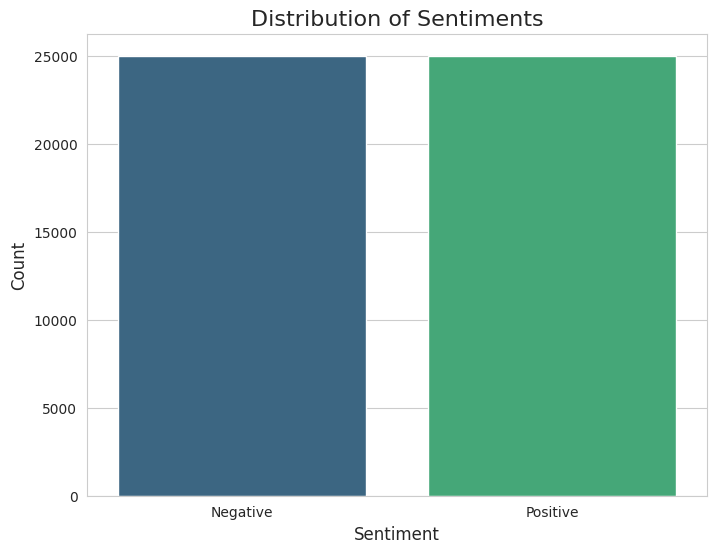

In [18]:
# Step 3: Exploratory Data Analysis (EDA) - Before Tuning
print("\nStep 3: Performing Exploratory Data Analysis (EDA)...")

# EDA 1: Sentiment Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiments', fontsize=16)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.show()

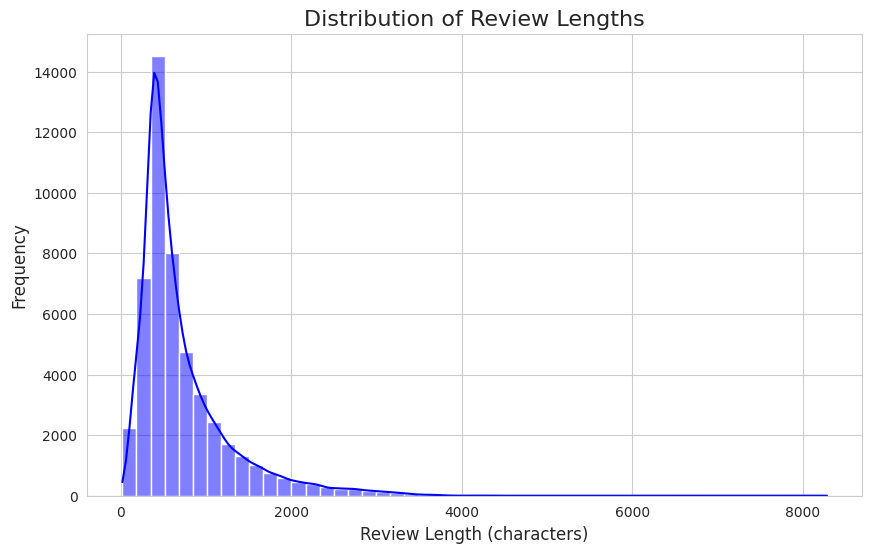

In [19]:
# EDA 2: Review Length Distribution
df['review_length'] = df['review'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(df['review_length'], bins=50, kde=True, color='blue')
plt.title('Distribution of Review Lengths', fontsize=16)
plt.xlabel('Review Length (characters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()



Generating Word Cloud...


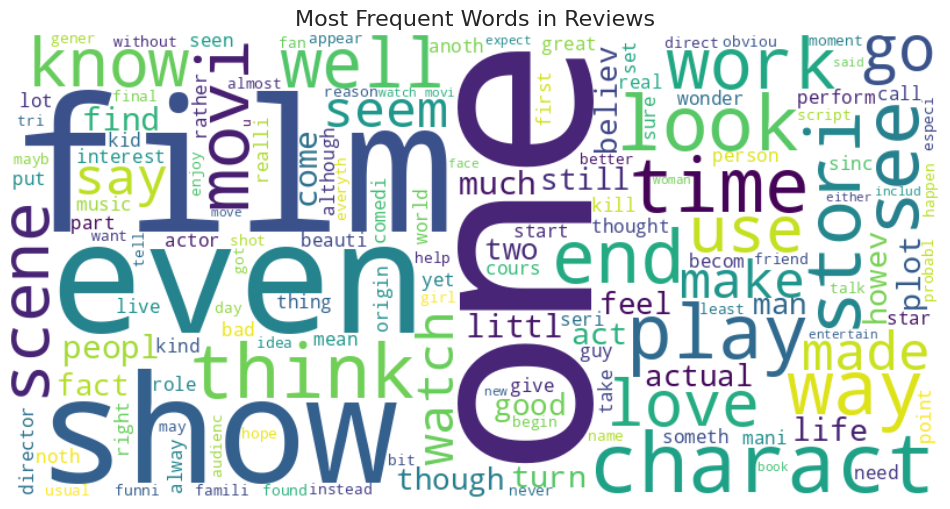

In [20]:
# EDA 3: Word Cloud
print("\nGenerating Word Cloud...")
# Combine all reviews into a single text
all_reviews = ' '.join(df['review'])

wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=150).generate(all_reviews)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Reviews', fontsize=16)
plt.show()



In [21]:
# Step 4: Feature Extraction (TF-IDF Vectorization)
print("\nStep 4: Performing TF-IDF Vectorization...")

# Fill missing values in 'review' column just in case
df['review'].fillna('', inplace=True)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X = vectorizer.fit_transform(df['review'])
y = df['sentiment']

# Save the vectorizer
vectorizer_path = '/content/drive/MyDrive/AIML assignment/results/vectorizer.pkl'
joblib.dump(vectorizer, vectorizer_path)
print(f"Vectorizer saved to {vectorizer_path}")

print(f"Shape of the TF-IDF feature matrix: {X.shape}")




Step 4: Performing TF-IDF Vectorization...


/tmp/ipython-input-4115628774.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['review'].fillna('', inplace=True)


Vectorizer saved to /content/drive/MyDrive/AIML assignment/results/vectorizer.pkl
Shape of the TF-IDF feature matrix: (50000, 5000)


In [22]:
# Step 5: Split Data into Training and Testing Sets
print("\nStep 5: Splitting data into training (80%) and testing (20%) sets...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print("\n")


Step 5: Splitting data into training (80%) and testing (20%) sets...
Training set size: 40000 samples
Testing set size: 10000 samples




In [23]:
# Step 6: Hyperparameter Tuning with GridSearchCV
print("Step 6: Performing hyperparameter tuning with GridSearchCV...")

# Define the parameter grid with 3 hyperparameters
param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # 'liblinear' is a good choice for this combination of penalties
}

# Initialize the GridSearchCV object
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print(f"Best parameters found: {grid_search.best_params_}")

# Display the results of each hyperparameter combination
print("\nHyperparameter Tuning Results:")
cv_results_df = pd.DataFrame(grid_search.cv_results_)

# Custom display for each tuning step
for i, params in enumerate(cv_results_df['params']):
    print(f"--- Tuning {i+1} ---")
    print(f"Parameters: {params}")
    print(f"Mean CV Accuracy: {cv_results_df['mean_test_score'][i]:.4f} (std: {cv_results_df['std_test_score'][i]:.4f})")
    print("-" * 20)


# Get the best model
model = grid_search.best_estimator_

print("\nHyperparameter tuning complete.")


Step 6: Performing hyperparameter tuning with GridSearchCV...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters found: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}

Hyperparameter Tuning Results:
--- Tuning 1 ---
Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Mean CV Accuracy: 0.8327 (std: 0.0049)
--------------------
--- Tuning 2 ---
Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Mean CV Accuracy: 0.8707 (std: 0.0037)
--------------------
--- Tuning 3 ---
Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Mean CV Accuracy: 0.8836 (std: 0.0037)
--------------------
--- Tuning 4 ---
Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Mean CV Accuracy: 0.8874 (std: 0.0036)
--------------------
--- Tuning 5 ---
Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Mean CV Accuracy: 0.8701 (std: 0.0035)
--------------------
--- Tuning 6 ---
Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}



Step 8: Evaluating the final model...

Final Model Accuracy: 0.8900 (89.00%)

Classification Report:
              precision  recall  f1-score   support
Negative       0.896503  0.8818  0.889091   5000.00
Positive       0.883707  0.8982  0.890895   5000.00
accuracy       0.890000  0.8900  0.890000      0.89
macro avg      0.890105  0.8900  0.889993  10000.00
weighted avg   0.890105  0.8900  0.889993  10000.00

Confusion Matrix:


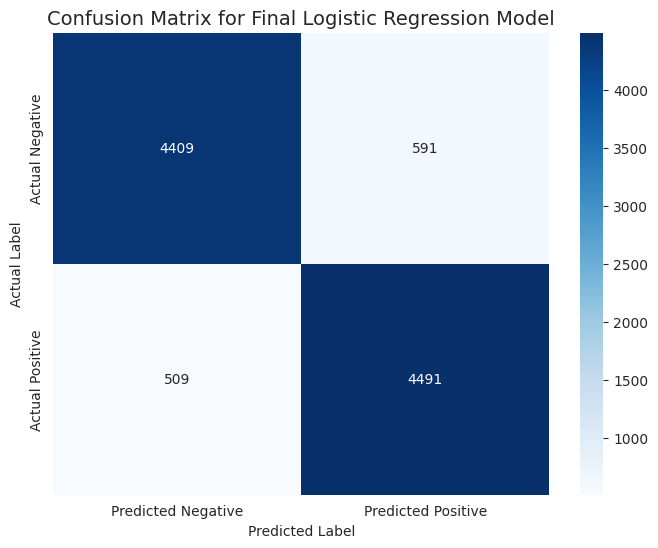

In [24]:
# Step 8: Evaluate the Final Model's Performance
print("\nStep 8: Evaluating the final model...")

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nFinal Model Accuracy: {accuracy:.4f} ({accuracy:.2%})")

print("\nClassification Report:")
report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], output_dict=True)
report_df = pd.DataFrame(report).transpose()
print(report_df)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for Final Logistic Regression Model', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


In [25]:
# Step 9: Save the results and the final model
print("\nStep 9: Saving the results and the model...")

# --- IMPORTANT ---
# Please update this path to your desired output folder in Google Drive.
results_dir = '/content/drive/MyDrive/AIML assignment/results/logistic_regression_results'
os.makedirs(results_dir, exist_ok=True)

# Save the classification report to a CSV file
report_df.to_csv(os.path.join(results_dir, 'classification_report.csv'))

# Save the confusion matrix plot
cm_plot_path = os.path.join(results_dir, 'confusion_matrix.png')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for Final Logistic Regression Model', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig(cm_plot_path)
plt.close()

# Save the accuracy to a text file
accuracy_path = os.path.join(results_dir, 'accuracy.txt')
with open(accuracy_path, 'w') as f:
    f.write(f'Final Model Accuracy: {accuracy:.4f} ({accuracy:.2%})')

# Save the trained model
model_path = os.path.join(results_dir, 'logistic_regression_model.pkl')
joblib.dump(model, model_path)

print(f"\nAll results and the final model have been saved to {results_dir}")



Step 9: Saving the results and the model...

All results and the final model have been saved to /content/drive/MyDrive/AIML assignment/results/logistic_regression_results
